In [ ]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import time

In [ ]:
DATA_DIR    = "/content/drive/MyDrive/CNN/seg_train/seg_train"
TEST_DIR    = "/content/drive/MyDrive/CNN/seg_test/seg_test"
IMG_SIZE    = 32
NUM_CLASSES = 6
EPOCHS      = 10
BATCH_SIZE  = 32
LR          = 0.001
MAX_SAMPLES = 3000

CLASSES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
def load_dataset(data_dir, max_samples=None):
    X, y = [], []
    for label, cls in enumerate(CLASSES):
        cls_dir = os.path.join(data_dir, cls)
        if not os.path.exists(cls_dir):
            print(f"[WARNING] Class folder not found: {cls_dir}")
            continue
        files = os.listdir(cls_dir)
        if max_samples:
            files = files[:max_samples // NUM_CLASSES]
        for fname in files:
            fpath = os.path.join(cls_dir, fname)
            try:
                img = Image.open(fpath).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
                arr = np.array(img, dtype=np.float32) / 255.0
                arr = arr.transpose(2, 0, 1)
                X.append(arr)
                y.append(label)
            except Exception:
                continue
    X = np.array(X)
    y = np.array(y, dtype=np.int32)

    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

In [ ]:
def one_hot(y, num_classes):
    oh = np.zeros((len(y), num_classes), dtype=np.float32)
    oh[np.arange(len(y)), y] = 1.0
    return oh

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(np.float32)

def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


In [ ]:
class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size):
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        k = kernel_size

        scale = np.sqrt(2.0 / (in_channels * k * k))
        self.W = np.random.randn(out_channels, in_channels, k, k).astype(np.float32) * scale
        self.b = np.zeros(out_channels, dtype=np.float32)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

        self.mW = np.zeros_like(self.W); self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b); self.vb = np.zeros_like(self.b)
        self.t  = 0

    def forward(self, x):
        self.x = x
        N, C, H, W = x.shape
        k = self.kernel_size
        Ho, Wo = H - k + 1, W - k + 1
        out = np.zeros((N, self.out_channels, Ho, Wo), dtype=np.float32)
        for i in range(Ho):
            for j in range(Wo):
                patch = x[:, :, i:i+k, j:j+k]

                out[:, :, i, j] = patch.reshape(N, -1) @ self.W.reshape(self.out_channels, -1).T
        out += self.b[np.newaxis, :, np.newaxis, np.newaxis]
        return out

    def backward(self, dout):
        x, W = self.x, self.W
        N, C, H, Wx = x.shape
        k = self.kernel_size
        Ho, Wo = H - k + 1, Wx - k + 1
        dx = np.zeros_like(x)
        self.dW[:] = 0
        self.db   = dout.sum(axis=(0, 2, 3))

        for i in range(Ho):
            for j in range(Wo):
                patch = x[:, :, i:i+k, j:j+k].reshape(N, -1)
                d     = dout[:, :, i, j]
                self.dW += (d.T @ patch).reshape(self.W.shape)
                dx[:, :, i:i+k, j:j+k] += (d @ W.reshape(self.out_channels, -1)).reshape(N, C, k, k)
        return dx

    def update(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for p, dp, m, v in [(self.W, self.dW, self.mW, self.vW),
                             (self.b, self.db, self.mb, self.vb)]:
            m[:] = beta1 * m + (1 - beta1) * dp
            v[:] = beta2 * v + (1 - beta2) * dp**2
            mc = m / (1 - beta1**self.t)
            vc = v / (1 - beta2**self.t)
            p -= lr * mc / (np.sqrt(vc) + eps)


class MaxPool2D:

    def forward(self, x):
        self.x = x
        N, C, H, W = x.shape
        Ho, Wo = H // 2, W // 2
        out = np.zeros((N, C, Ho, Wo), dtype=np.float32)
        self.mask = np.zeros_like(x, dtype=bool)
        for i in range(Ho):
            for j in range(Wo):
                patch = x[:, :, i*2:i*2+2, j*2:j*2+2]
                mx = patch.max(axis=(2, 3), keepdims=True)
                out[:, :, i, j] = mx[:, :, 0, 0]
                self.mask[:, :, i*2:i*2+2, j*2:j*2+2] = (patch == mx)
        return out

    def backward(self, dout):
        dx = np.zeros_like(self.x)
        N, C, Ho, Wo = dout.shape
        for i in range(Ho):
            for j in range(Wo):
                dx[:, :, i*2:i*2+2, j*2:j*2+2] += (
                    self.mask[:, :, i*2:i*2+2, j*2:j*2+2] *
                    dout[:, :, i, j][:, :, np.newaxis, np.newaxis]
                )
        return dx


In [ ]:
class ReLULayer:
    def forward(self, x):
        self.x = x
        return relu(x)

    def backward(self, dout):
        return dout * relu_grad(self.x)

In [ ]:
class Flatten:
    def forward(self, x):
        self.shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, dout):
        return dout.reshape(self.shape)

In [ ]:
class Dense:
    def __init__(self, in_features, out_features):
        scale = np.sqrt(2.0 / in_features)
        self.W = np.random.randn(in_features, out_features).astype(np.float32) * scale
        self.b = np.zeros(out_features, dtype=np.float32)
        self.mW = np.zeros_like(self.W); self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b); self.vb = np.zeros_like(self.b)
        self.t  = 0

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW = self.x.T @ dout
        self.db = dout.sum(axis=0)
        return dout @ self.W.T

    def update(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for p, dp, m, v in [(self.W, self.dW, self.mW, self.vW),
                             (self.b, self.db, self.mb, self.vb)]:
            m[:] = beta1 * m + (1 - beta1) * dp
            v[:] = beta2 * v + (1 - beta2) * dp**2
            mc = m / (1 - beta1**self.t)
            vc = v / (1 - beta2**self.t)
            p -= lr * mc / (np.sqrt(vc) + eps)


In [ ]:
class CNN:
    def __init__(self):
        self.layers = [
            Conv2D(3, 16, 3),
            ReLULayer(),
            MaxPool2D(),
            Conv2D(16, 32, 3),
            ReLULayer(),
            MaxPool2D(),
            Flatten(),
            Dense(32 * 6 * 6, 128),
            ReLULayer(),
            Dense(128, NUM_CLASSES),
        ]

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, dout):
        for layer in reversed(self.layers):
            dout = layer.backward(dout)

    def update(self, lr):
        for layer in self.layers:
            if hasattr(layer, 'update'):
                layer.update(lr)


In [ ]:
def cross_entropy_loss(logits, y_oh):
    probs = softmax(logits)
    N = len(y_oh)
    loss = -np.sum(y_oh * np.log(probs + 1e-9)) / N
    dlogits = (probs - y_oh) / N
    return loss, dlogits, probs


In [ ]:
def train(model, X_train, y_train, X_test, y_test):
    N = len(X_train)
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(1, EPOCHS + 1):

        idx = np.random.permutation(N)
        X_train, y_train = X_train[idx], y_train[idx]
        y_oh = one_hot(y_train, NUM_CLASSES)

        epoch_loss, correct = 0.0, 0
        num_batches = N // BATCH_SIZE

        for b in tqdm(range(num_batches), desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
            xb = X_train[b*BATCH_SIZE:(b+1)*BATCH_SIZE]
            yb = y_oh[b*BATCH_SIZE:(b+1)*BATCH_SIZE]

            logits = model.forward(xb)
            loss, dlogits, probs = cross_entropy_loss(logits, yb)
            model.backward(dlogits)
            model.update(LR)

            epoch_loss += loss
            correct    += (probs.argmax(1) == yb.argmax(1)).sum()

        train_acc = correct / (num_batches * BATCH_SIZE)
        test_acc  = evaluate(model, X_test, y_test)
        avg_loss  = epoch_loss / num_batches

        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%")

    return history

In [ ]:
def evaluate(model, X, y, batch_size=64):
    correct, total = 0, 0
    for b in range(0, len(X), batch_size):
        xb = X[b:b+batch_size]
        yb = y[b:b+batch_size]
        logits = model.forward(xb)
        preds  = logits.argmax(axis=1)
        correct += (preds == yb).sum()
        total   += len(yb)
    return correct / total

In [ ]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history['train_loss'], marker='o', color='royalblue', label='Train Loss')
    axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], marker='o', color='green',  label='Train Acc')
    axes[1].plot(history['test_acc'],  marker='s', color='orange', label='Test Acc')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
def demo_with_random_data():

    print("=" * 60)
    print("DEMO MODE — running on synthetic random data")
    print("(Replace with real Intel Image Classification data)")
    print("=" * 60)
    np.random.seed(42)
    N_train, N_test = 320, 64
    X_train = np.random.randn(N_train, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)
    y_train = np.random.randint(0, NUM_CLASSES, N_train)
    X_test  = np.random.randn(N_test,  3, IMG_SIZE, IMG_SIZE).astype(np.float32)
    y_test  = np.random.randint(0, NUM_CLASSES, N_test)
    return X_train, y_train, X_test, y_test

CNN from Scratch — Intel Image Classification
Loading data from /content/drive/MyDrive/CNN/seg_train/seg_train ...
Train: (3000, 3, 32, 32)  Test: (600, 3, 32, 32)

Model Architecture:
  Conv2D(3→16, 3×3) → ReLU → MaxPool2D
  Conv2D(16→32, 3×3) → ReLU → MaxPool2D
  Flatten → Dense(1152→128) → ReLU → Dense(128→6) → Softmax



Epoch 01 | Loss: 1.3912 | Train Acc: 43.28% | Test Acc: 54.00%


Epoch 02 | Loss: 1.0082 | Train Acc: 62.43% | Test Acc: 56.50%


Epoch 03 | Loss: 0.8756 | Train Acc: 67.94% | Test Acc: 64.50%


Epoch 04 | Loss: 0.7848 | Train Acc: 70.53% | Test Acc: 66.17%


...

Epoch 06 | Loss: 0.6424 | Train Acc: 76.92% | Test Acc: 66.67%


Epoch 07 | Loss: 0.5828 | Train Acc: 79.23% | Test Acc: 67.33%


Epoch 08 | Loss: 0.5356 | Train Acc: 80.85% | Test Acc: 67.50%


Epoch 09 | Loss: 0.4671 | Train Acc: 83.64% | Test Acc: 68.67%


Epoch 10 | Loss: 0.4256 | Train Acc: 85.25% | Test Acc: 66.67%

Training complete in 253.3s
Final Test Accuracy: 66.67%


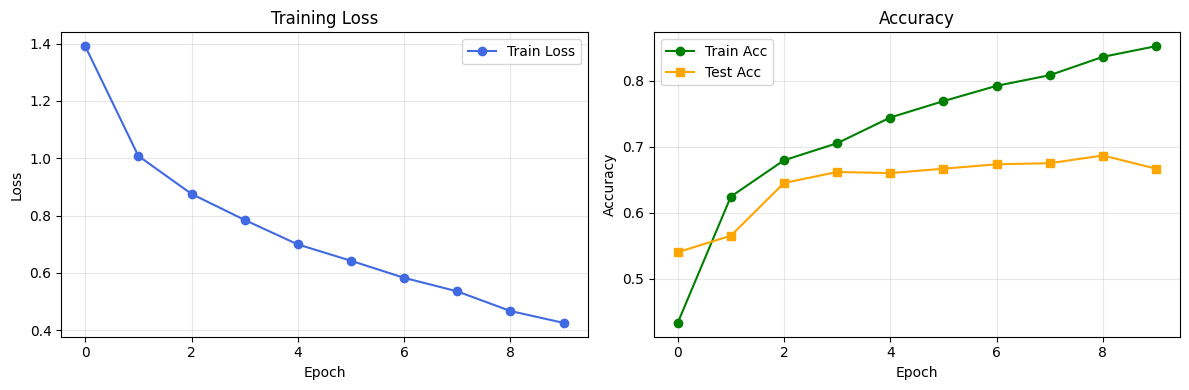

Model weights saved to cnn_weights.pkl


In [ ]:
if __name__ == "__main__":
    np.random.seed(42)
    print("CNN from Scratch — Intel Image Classification")

    if os.path.exists(DATA_DIR):
        print(f"Loading data from {DATA_DIR} ...")
        X_train, y_train = load_dataset(DATA_DIR, max_samples=MAX_SAMPLES)
        X_test,  y_test  = load_dataset(TEST_DIR,  max_samples=MAX_SAMPLES // 5)
        print(f"Train: {X_train.shape}  Test: {X_test.shape}\n")
    else:
        print(f"[INFO] Dataset not found at '{DATA_DIR}'. Running DEMO with random data.\n")
        X_train, y_train, X_test, y_test = demo_with_random_data()

    model = CNN()
    print("Model Architecture:")
    print("  Conv2D(3→16, 3×3) → ReLU → MaxPool2D")
    print("  Conv2D(16→32, 3×3) → ReLU → MaxPool2D")
    print("  Flatten → Dense(1152→128) → ReLU → Dense(128→6) → Softmax\n")

    start = time.time()
    history = train(model, X_train, y_train, X_test, y_test)
    elapsed = time.time() - start

    print(f"\nTraining complete in {elapsed:.1f}s")
    print(f"Final Test Accuracy: {history['test_acc'][-1]*100:.2f}%")

    plot_history(history)

    weights = {}
    for i, layer in enumerate(model.layers):
        if isinstance(layer, (Conv2D, Dense)):
            weights[f"layer_{i}_W"] = layer.W
            weights[f"layer_{i}_b"] = layer.b
    with open("cnn_weights.pkl", "wb") as f:
        pickle.dump(weights, f)
    print("Model weights saved to cnn_weights.pkl")